In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import math

In [22]:
from pred.data import data, continuous, categorical
from pred.NaiveBayes import NaiveBayesClassifier
from pred.LogisticRegression import MyLogisticRegression

datapath = "../data/adult.data.clean.csv"
d = data(datapath)
continuous_labels = list(continuous(d).keys())
categorical_labels = list(categorical(d).keys())
features = list(continuous_labels + categorical_labels)

NB = NaiveBayesClassifier(datapath)
LR = MyLogisticRegression(datapath)

In [23]:
# > 100 coefficients; one hot encoding expands the number of features
# ex: 'x0_Federal-gov' 'x0_Local-gov' 'x0_Private' 'x0_Self-emp-inc'
#  'x0_Self-emp-not-inc' 'x0_State-gov' 'x0_Without-pay' 'x1_10th' 'x1_11th'
# print(model.model.coef_)
# unwrap coefficients
import math 
from pprint import pprint

cont_coeff = {feature: [] for feature in continuous_labels}
cat_coeff = {feature: [] for feature in categorical_labels}
cat_names = LR.enc.get_feature_names_out()

# we can just use the first 5 continuous coefficients
for i in range(5):
    ft = features[i]
    cont_coeff[ft].append((ft, float(LR.model.coef_[0][i])))

for i in range(len(cat_names)):
    ft_index = 5+int(cat_names[i].split('_')[0][1])
    ft = features[ft_index]
    ft_cat = cat_names[i].split('_')[1]

    val = LR.model.coef_[0][i+5]
    cat_coeff[ft].append((ft_cat, float(val)))

# sort
for i in range(len(categorical_labels)):
    ls = cat_coeff[categorical_labels[i]]
    ls.sort(key= lambda x: x[1])

coeffs = cont_coeff | cat_coeff

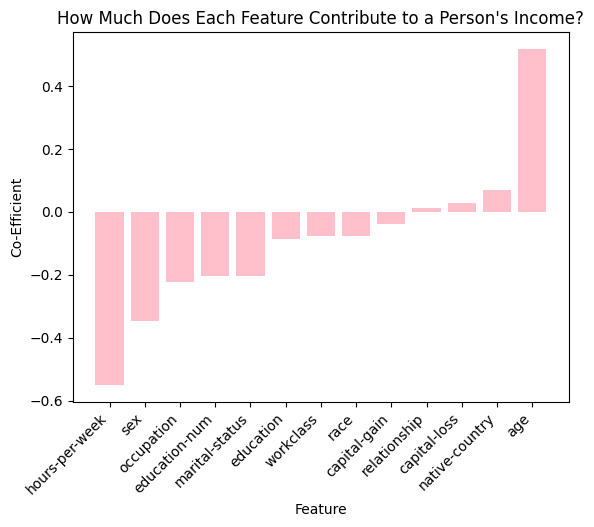

In [24]:
Y = [sum(x[1] for x in coeffs[key])/len(coeffs[key]) for key in coeffs.keys()]

df = pd.DataFrame({
    'feature': coeffs.keys(),
    'coeff': Y
})
df = df.sort_values('coeff')
plt.bar(df['feature'], df['coeff'], color="pink")
ax = plt.gca()
# ax.set_facecolor('black')
plt.xticks(rotation=45, ha='right')
plt.title("How Much Does Each Feature Contribute to a Person's Income?")
plt.xlabel('Feature')
plt.ylabel('Co-Efficient')
plt.show()

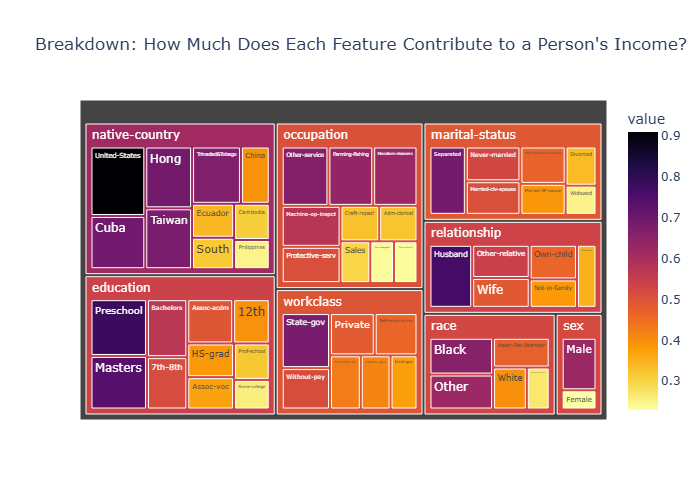

In [98]:
import plotly.express as px
import plotly.io as pio

# pio.renderers.default = "notebook"
pio.renderers.default = 'png' 

def sigmoid(x):
    return  (math.e**x)/(1+(math.e**x))

rows = []
for feature, entries in cat_coeff.items():
    if len(entries) >= 11:
        entries = entries[:5] + entries[-5:]
    for label, value in entries:
        rows.append({'feature': feature, 'category': label, 'value': sigmoid(value)})

df = pd.DataFrame(rows)
px.treemap(df,path=['feature', 'category'],values='value',color='value',color_continuous_scale='Inferno_r', title="Breakdown: How Much Does Each Feature Contribute to a Person's Income?")

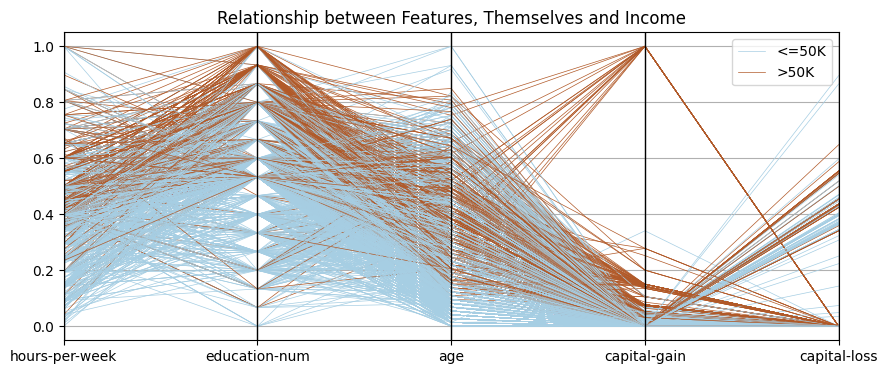

In [26]:
aug = continuous(d)
df = pd.DataFrame(aug)
df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]
# normalize
df = (df-df.min())/(df.max()-df.min())
# meaningfully order
column_order = ['hours-per-week','education-num','age', 'capital-gain', 'capital-loss']
df = df[column_order]
df['Y'] = d['f14']
# shuffle and reduce
df = df.sample(frac=0.1, random_state=42)
plt.figure(figsize=(10,4))
plt.title('Relationship between Features, Themselves and Income')
pd.plotting.parallel_coordinates(df, 'Y', colormap='Paired', lw=0.5)
plt.show()

In [27]:
import geopandas as gpd

df = pd.DataFrame(d)
df.insert(0,'Y',d['f14'])
df = df[['f13','Y']]

df = df.replace('-', ' ', regex=True)
df = df.replace('United States', 'United States of America', regex=True)
df = df.rename(columns={'f13':'SOVEREIGNT'})

df_sub50 = np.log(df[df['Y'] == '<=50K'].groupby('SOVEREIGNT').count())
df_over50 = np.log(df[df['Y'] == '>50K'].groupby('SOVEREIGNT').count())
df_sub50['COUNT SUB'] = np.log1p(df_sub50['Y']+0.01).clip(0,4.5)
df_over50['COUNT OVER'] = np.log1p(df_over50['Y']+0.01).clip(0,4.5)

df_ratio = df_sub50.merge(df_over50, on="SOVEREIGNT")
df_ratio['RATIO'] = np.log(df_ratio['COUNT SUB']/df_ratio['COUNT OVER']).clip(0,1)
# print(df_ratio['RATIO'])

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

augment = world.merge(df_ratio, on='SOVEREIGNT')

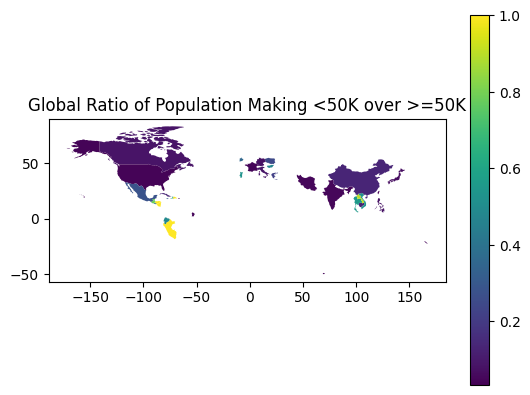

In [28]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#     print(augment)
augment.plot(column='RATIO', legend=True)
plt.title('Global Ratio of Population Making <50K over >=50K')
plt.show()

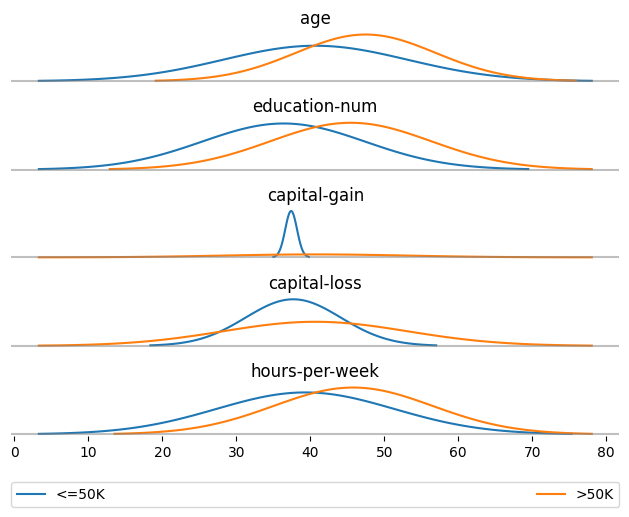

In [96]:
# Normal Graphs Sparklines
means = NB.gnb.theta_
vars = NB.gnb.var_
classes = NB.gnb.classes_

def line(mean, var):
    return np.linspace(mean - 3*math.sqrt(var), mean + 3*math.sqrt(var), 100)

fig, axes = plt.subplots(5,1)
for i in range(len(continuous_labels)):
    feat_sub50 = line(means[0][i], vars[0][i])
    feat_over50 =  line(means[1][i], vars[1][i])
    feat_name = continuous_labels[i]

    ax = axes[i]
    ax.plot(feat_sub50, stats.norm.pdf(feat_sub50, means[0][i], math.sqrt(vars[0][i])))
    ax.plot(feat_over50, stats.norm.pdf(feat_over50, means[1][i], math.sqrt(vars[1][i])))
    ax.axhline(c='grey', alpha=0.5)
    ax.set_title(feat_name)

for ax in axes:
    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.setp(ax.get_xticklines(), visible=False)
    plt.setp(ax.get_yticklines(), visible=False)
    plt.setp(ax.spines.values(), visible=False)

plt.setp(axes[-1].get_xticklabels(), visible=True)
plt.setp(axes[-1].get_xticklines(), visible=True)
axes[-1].xaxis.tick_bottom() 
plt.tight_layout()

plt.legend(classes, bbox_to_anchor=(0., -1, 1., .102),ncols=2, mode="expand", borderaxespad=0.)
plt.show()


In [30]:
# scatter plots between each continuous variable and colored with the label
# show potential correlation and clustering

In [31]:
# Stacked bar charts for other categorical data to show exactly who is making what